In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import os
import sys
import random
from scipy.linalg import cho_solve, cho_factor
from sklearn.metrics import r2_score, mean_squared_error

### In this tutorial, we will:


1. Draw samples from GP prior   
2. Explore the regularization
3. Load a small dataset of **DFT-calculated C structures**.
4. Compute **SOAP descriptors** to represent atomic environments.
5. Write a simple **GAP** model ourselvs. 
6. Train a **GAP** model to predict energies.
7. Train a **GAP** model with gap_fit code.
   

### Requirements:
- `ase`
- `quippy`
- `matplotlib`
- `numpy`
- `gap_fit`


## Regularization

We will start by seeing how to draw samples from a GP prior, where 

$$
y \sim \mathcal{N}(0, K(X, X))
$$

So we will need to decide on a domain for $X$ and implement a kernel function $K$.
We will start using the radial basis function (RBF) kernel, 

$$
K(x, x^*) = \exp{\left(-\frac{|x-x^*|^2}{2\lambda^2}\right)}
$$
With $|x|$ being the euclidean distance of $x$. 
  $$
\mathrm{Var}(x) = K(x_*, x_*) + \sigma - K(x_*, x) (K(x,x) + \sigma^2 I)^{-1} K(x,x_*)
$$
**Log marginal likelihood** a measure of how well the Gaussian Process with given hyperparameters explains the observed data, balancing data fit and model complexity.

$$
\begin{equation}
\begin{aligned}
\mathrm{LML} = \log p(y | X ) =& -\frac{1}{2} \mathbf{y}^T(K(X, X) + \sigma^2_n I)^{-1}\mathbf{y} \\
& -\frac{1}{2} \log |K(X, X) + \sigma^2_n I| \\
& - \frac{n}{2} \log 2\pi
\end{aligned}
\end{equation}
$$
1. Data fit - how well do the function in the distribution fit the data?
2. Model complexity - how complex is the model? 
3. A normalization constant. 
In the cell below, implement the RBF kernel 


In [2]:
def f(x):
    return np.sin(2 * np.pi * x)

# Training data
n_train = 20
X_train = np.sort(np.random.uniform(-1.0, 1.0, size=n_train))[:, None]
y_train = f(X_train).ravel() + 0.15 * np.random.randn(n_train)

# Test date
X_test = np.linspace(-1.2, 1.2, 400)[:, None]
y_true = f(X_test).ravel()

In [3]:
def rbf_kernel(X1, X2, length_scale):
    d2 = cdist(X1, X2, metric="sqeuclidean")
    return np.exp(-0.5 * d2 / length_scale**2)

In [5]:
def gp_predict(X_train, y_train, X_test, length_scale=0.3, noise=1e-2):
    # Kernel matrices
    K = rbf_kernel(X_train, X_train, length_scale) + noise**2 * np.eye(len(X_train))
    Ks = rbf_kernel(X_test, X_train, length_scale)
    Kss = rbf_kernel(X_test, X_test, length_scale)

    # Cholesky solve
    L, lower = cho_factor(K, lower=True)
    alpha = cho_solve((L, lower), y_train)

    # Posterior mean
    mean = Ks @ alpha

    # Posterior covariance
    v = cho_solve((L, lower), Ks.T)
    cov = Kss - Ks @ v
    var = np.clip(np.diag(cov), 0, None)

    return mean, var, cov, (L, lower, alpha)

In [6]:
def log_marginal_likelihood(X_train, y_train, length_scale=0.3, noise=1e-2):
    K = rbf_kernel(X_train, X_train, length_scale) + noise**2 * np.eye(len(X_train))
    L, lower = cho_factor(K, lower=True)

    alpha = cho_solve((L, lower), y_train)

    lml = (
        -0.5 * y_train @ alpha
        - np.sum(np.log(np.diag(L)))
        - 0.5 * len(X_train) * np.log(2 * np.pi)
    )
    return lml

In [8]:
def plot_gp(ax, X_train, y_train, X_test, y_true, length_scale, noise):
    mean, var, _, _ = gp_predict(
        X_train, y_train, X_test,
        length_scale=length_scale,
        noise=noise
    )

    std = np.sqrt(var)

    
    ax.plot(X_test, mean, label="GP mean")
    ax.fill_between(
        X_test.ravel(),
        mean - 2 * std,
        mean + 2 * std,
        alpha=0.25,
        label="var"
    )
    ax.scatter(X_train, y_train, color="red", zorder=3, label="Training data")
    ax.set_title(f"length={length_scale:.2f}, regularization={noise:.3f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

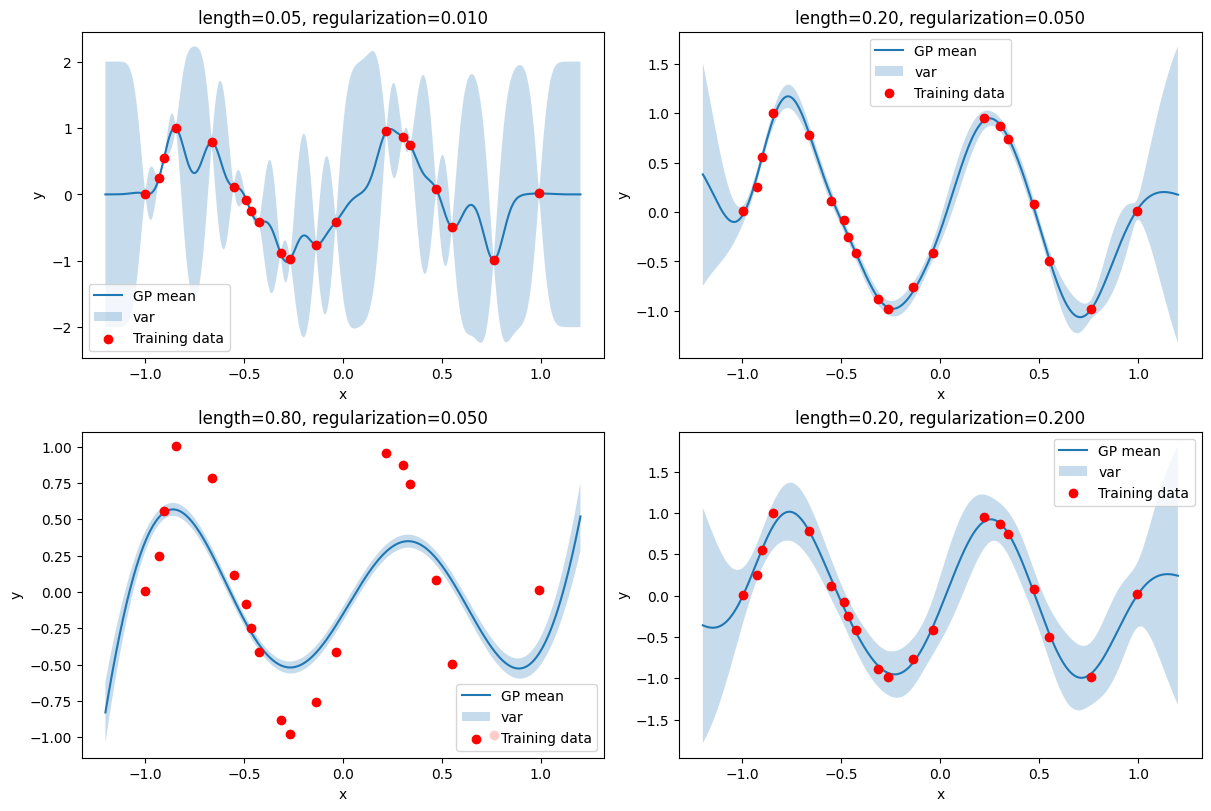

In [9]:
settings = [
    (0.05, 0.01),  # length and regularization/noise
    (0.20, 0.05),  
    (0.80, 0.05),   
    (0.20, 0.20),   
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

for ax, (length_scale, noise) in zip(axes.ravel(), settings):
    plot_gp(ax, X_train, y_train, X_test, y_true, length_scale, noise)

plt.show()

### The marginal log likelihood lets us evaluate the model's ability to describe the data, allowing us to pick appropriate hyperparameters.

In [1]:
length_scales = np.geomspace(0.03, 1.5, 60)
noise_levels = np.geomspace(0.005, 0.4, 60)

LML = np.zeros((len(noise_levels), len(length_scales)))

for i, noise in enumerate(noise_levels):
    for j, length_scale in enumerate(length_scales):
        LML[i, j] = log_marginal_likelihood(
            X_train, y_train,
            length_scale=length_scale,
            noise=noise
        )

NameError: name 'np' is not defined

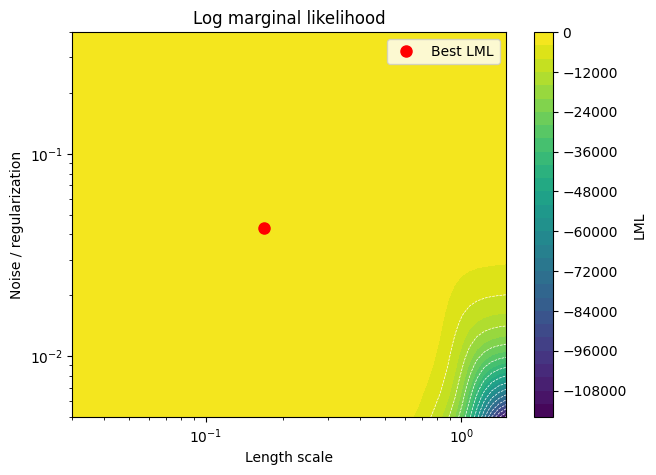

Best length scale = 0.1682
Best noise        = 0.0431


In [11]:
best_idx = np.unravel_index(np.argmax(LML), LML.shape)
best_noise = noise_levels[best_idx[0]]
best_length = length_scales[best_idx[1]]

fig, ax = plt.subplots(figsize=(7, 5))

contour = ax.contourf(length_scales, noise_levels, LML, levels=30, cmap="viridis")
ax.contour(length_scales, noise_levels, LML, levels=15, colors="white", linewidths=0.5)

ax.plot(best_length, best_noise, "ro", markersize=8, label="Best LML")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Length scale")
ax.set_ylabel("Noise / regularization")
ax.set_title("Log marginal likelihood")
ax.legend()

fig.colorbar(contour, ax=ax, label="LML")
plt.show()

print(f"Best length scale = {best_length:.4f}")
print(f"Best noise        = {best_noise:.4f}")

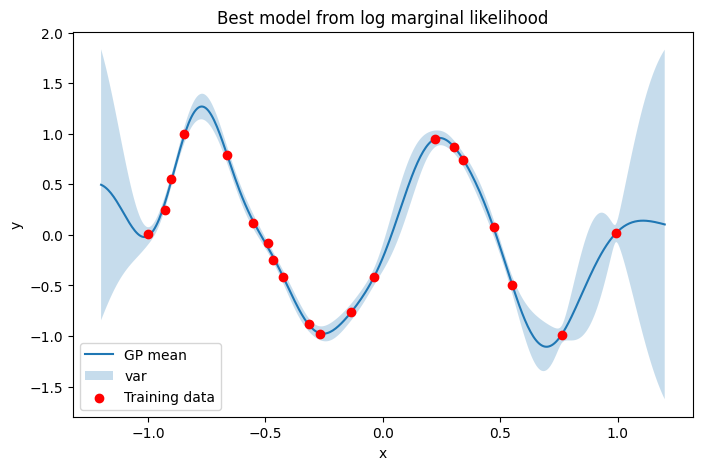

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_gp(ax, X_train, y_train, X_test, y_true, best_length, best_noise)
ax.set_title("Best model from log marginal likelihood")
plt.show()

In [2]:
import ipywidgets as widgets
from ipywidgets import interact

@interact(length_scale=(0.03, 1.5, 0.02), noise=(0.005, 0.4, 0.005))
def interactive_gp(length_scale=0.2, noise=0.05):
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_gp(ax, X_train, y_train, X_test, y_true, length_scale, noise)
    lml = log_marginal_likelihood(X_train, y_train, length_scale, noise)
    ax.set_title(f"length={length_scale:.2f}, regularization={noise:.3f}, LML={lml:.2f}")
    plt.show()

interactive(children=(FloatSlider(value=0.2, description='length_scale', max=1.5, min=0.03, step=0.02), FloatS…

## GAP regularization

In this notebook, we build a Gaussian Process Regression (GPR) model to predict atomic energies from SOAP (Smooth Overlap of Atomic Positions) descriptors.
We assume a local energy model:


$$E = \sum_{i=1}^{N} E_i(\mathbf{p}_i)$$

Where:

- $E_i$ is the local energy of atom _i_,

- $\mathbf{p}_i$ is the SOAP vector of atom _i_
  
$$E_{\text{total}}^{\text{test}} = \sum_{i \in \text{test}} \sum_{j \in \text{train}} \alpha_j \cdot k(\mathbf{p}_i, \mathbf{p}_j)$$
   
- $k(\mathbf{p}_i, \mathbf{p}_j)$ is the SOAP kernel
- $\alpha_j$ is the coefficient from GPR training
$$
\alpha_{\mathrm{opt}} = \arg\min_{\alpha} \left( \|K\alpha - y\|^2 + \sigma^2 \|\alpha\|^2 \right)
$$

The fitting coefficients can be then obtained from matrix inversion:
$$
\alpha = (K + \sigma^2 I)^{-1} y
$$
- $\alpha$ is a weight vector (length = number of training data points)              
- $ K $ is a kernel matrix, with entries $ K_{ij} = k(\mathbf{x}_i, \mathbf{x}_j)$

- $\sigma^2$ is a regularization parameter
- $I$ - Identity matrix (same shape as \( K \))                                
- $ y$ - vector of training targets (e.g., atomic energies)
  $$
\mathrm{Var}(x) = K(x_*, x_*) + \sigma - K(x_*, x) (K(x,x) + \sigma^2 I)^{-1} K(x,x_*)
$$

In [22]:
pip install quippy-ase

Note: you may need to restart the kernel to use updated packages.


In [23]:
from quippy.descriptors import Descriptor 
from ase.io import read, write

In [14]:
# Descriptor string 
soap_str = "soap cutoff=3 l_max=4 n_max=4 atom_sigma=0.5 n_Z=1 Z1=6"



*l_max=4* -  spherical harmonics are expanded up to angular momentum 4

*n_max=4* - the radial basis expansion uses 4 radial basis functions

*atom_sigma* - width of a Gaussian function

In [24]:
# Initialize SOAP descriptor
soap_descriptor = Descriptor(soap_str)

In [64]:
def split_xyz(input_file, test_size=0.2, seed=42):

    structures = read(input_file, index=":")
    print(f"Loaded {len(structures)} structures from {input_file}")

    random.seed(seed)
    random.shuffle(structures)

    split_idx = int(len(structures) * (1 - test_size))
    train_structures = structures[:split_idx]
    test_structures = structures[split_idx:]

    input_name = os.path.basename(input_file).split('.')[0]

    train_file = f"{input_name}_train.xyz"
    test_file = f"{input_name}_test.xyz"

    write(train_file, train_structures)
    write(test_file, test_structures)

    print(f"Split complete: {len(train_structures)} train, {len(test_structures)} test")

    return train_file, test_file

In [50]:
def parity_plot(y_true, y_pred, title="Parity plot"):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, s=20, alpha=0.7)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], "k--")
    plt.xlabel("DFT energy / atom (eV)")
    plt.ylabel("Predicted energy / atom (eV)")
    plt.title(title)
    plt.text(
        0.05, 0.95,
        f"R² = {r2:.3f}\nRMSE = {rmse:.4f} eV",
        transform=plt.gca().transAxes,
        va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )
    plt.tight_layout()
    plt.show()

In [52]:
def make_soap_descriptor(atom_sigma=0.5, cutoff=3.0, l_max=4, n_max=4):
    soap_str = (
        f"soap cutoff={cutoff} "
        f"l_max={l_max} "
        f"n_max={n_max} "
        f"atom_sigma={atom_sigma} "
        f"n_Z=1 Z1=6"
    )
    return Descriptor(soap_str)

In [65]:
train_file, test_file = split_xyz("bulk_cryst.xyz", test_size=0.45, seed=42)

train_structures = read(train_file, ":")
test_structures = read(test_file, ":")

print(f"Train structures: {len(train_structures)}")
print(f"Test structures: {len(test_structures)}")

Loaded 356 structures from bulk_cryst.xyz


/opt/conda/lib/python3.11/site-packages/ase/io/extxyz.py:1000: UserWarning: write_xyz() overwriting array "forces" present in atoms.arrays with stored results from calculator
  warnings.warn('write_xyz() overwriting array "{0}" present '


Split complete: 195 train, 161 test
Train structures: 195
Test structures: 161


#### Compute SOAP descriptors and Energy per atom

We have a total energy of the structure. However, in order to learn our fitting coefficients, we need a decomposition of energy. What if we simply assume that energy can be devided by the number of atoms in the structure?
We assign per-atom energies by dividing the total energy of the structure equally among its atoms (simple assumption). Then each atom gets a SOAP descriptor. 



In [71]:
X_all=[] # List of arrays
e_all=[] # List of atomic energies

for atoms in train_structures:
    E_total = atoms.get_potential_energy()
    
    # Get per-atom SOAP (unnormalized)
    desc = soap_descriptor.calc(atoms, descriptor_only=True)
    X_atoms = desc['data']
    # Assign per-atom energies equally (can be improved!)
    E_per_atom = E_total / len(atoms)
    e_atoms = np.full(len(atoms), E_per_atom)

    X_all.append(X_atoms)
    e_all.append(e_atoms)
# Stack all training data
X_train = np.vstack(X_all)   # shape (N_atoms_total, D)
e_train = np.concatenate(e_all) 
print("X_train shape:", X_train.shape)
print("e_train shape:", e_train.shape)

X_train shape: (1196, 51)
e_train shape: (1196,)


X_train shape: (1196, 51)
e_train shape: (1196,)


#### We need to compute the SOAP kernel between each pair of training descriptors 
The resulting matrix K is a kernel matrix, where each entry K[i, j] measures similarity between atomic environments i and j.

In [55]:
def soap_kernel_matrix(X1, X2, zeta=4):
    K = np.dot(X1, X2.T)
    return K ** zeta


In [56]:
def train_gap_like_model(X_train, e_train, sigma_n=1e-2, zeta=4):
    K = soap_kernel_matrix(X_train, X_train, zeta=zeta)
    K += sigma_n**2 * np.eye(len(X_train))

    L = np.linalg.cholesky(K)
    y1 = np.linalg.solve(L, e_train)
    alpha = np.linalg.solve(L.T, y1)

    return alpha, K, L

In [57]:
def predict_structure_energy(atoms, descriptor, X_train, alpha, zeta=4):
    desc = descriptor.calc(atoms, descriptor_only=True)
    X_test = desc["data"]

    K_test = soap_kernel_matrix(X_test, X_train, zeta=zeta)
    local_energies = K_test @ alpha

    return np.sum(local_energies)

In [58]:
def predict_dataset(structures, descriptor, X_train, alpha, zeta=4):
    E_pred_total = [predict_structure_energy(a, descriptor, X_train, alpha, zeta=zeta)
                    for a in structures]
    E_pred_atom = [E_pred_total[i] / len(structures[i]) for i in range(len(structures))]
    E_true_atom = [a.get_potential_energy() / len(a) for a in structures]

    return np.array(E_true_atom), np.array(E_pred_atom)

X_train shape: (1196, 51)
e_train shape: (1196,)


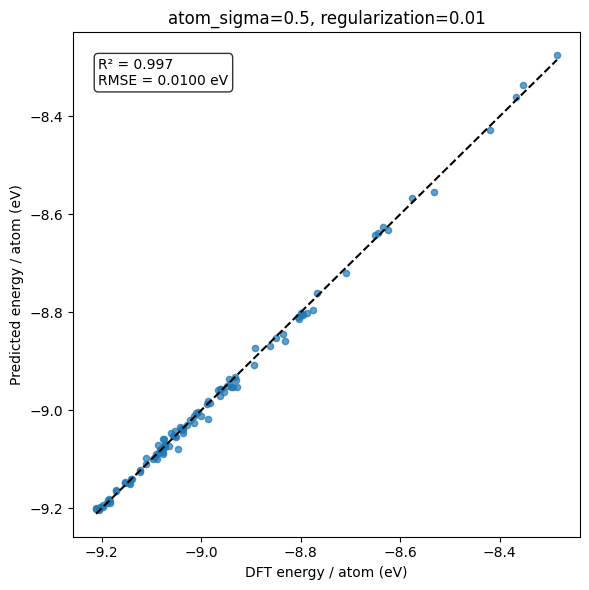

In [63]:
atom_sigma = 0.5
sigma_n = 1e-2
zeta = 4

soap_descriptor = make_soap_descriptor(atom_sigma=atom_sigma)
#X_train, e_train = build_atomic_dataset(train_structures, soap_descriptor)

print("X_train shape:", X_train.shape)
print("e_train shape:", e_train.shape)

alpha, K, L = train_gap_like_model(X_train, e_train, sigma_n=sigma_n, zeta=zeta)

y_true, y_pred = predict_dataset(test_structures, soap_descriptor, X_train, alpha, zeta=zeta)
parity_plot(y_true, y_pred, title=f"atom_sigma={atom_sigma}, regularization={sigma_n}")

In [67]:
atom_sigmas = [0.2, 0.35, 0.5, 0.7, 1.0]
sigma_ns = [1e-4, 1e-3, 1e-2, 1e-1, 3e-1]

results = []

for atom_sigma in atom_sigmas:
    descriptor = make_soap_descriptor(atom_sigma=atom_sigma)
    #X_train, e_train = build_atomic_dataset(train_structures, descriptor)

    for sigma_n in sigma_ns:
        alpha, K, L = train_gap_like_model(X_train, e_train, sigma_n=sigma_n, zeta=4)
        y_true, y_pred = predict_dataset(test_structures, descriptor, X_train, alpha, zeta=4)

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)

        results.append({
            "atom_sigma": atom_sigma,
            "regularization": sigma_n,
            "rmse": rmse,
        })

results

[{'atom_sigma': 0.2,
  'regularization': 0.0001,
  'rmse': np.float64(69.20907005211316)},
 {'atom_sigma': 0.2,
  'regularization': 0.001,
  'rmse': np.float64(9.797198806490723)},
 {'atom_sigma': 0.2,
  'regularization': 0.01,
  'rmse': np.float64(8.053084875715932)},
 {'atom_sigma': 0.2,
  'regularization': 0.1,
  'rmse': np.float64(8.193151099927297)},
 {'atom_sigma': 0.2,
  'regularization': 0.3,
  'rmse': np.float64(7.9909170549647515)},
 {'atom_sigma': 0.35,
  'regularization': 0.0001,
  'rmse': np.float64(10.770600359795182)},
 {'atom_sigma': 0.35,
  'regularization': 0.001,
  'rmse': np.float64(4.885687746281999)},
 {'atom_sigma': 0.35,
  'regularization': 0.01,
  'rmse': np.float64(1.2949924961277257)},
 {'atom_sigma': 0.35,
  'regularization': 0.1,
  'rmse': np.float64(3.914739194278932)},
 {'atom_sigma': 0.35,
  'regularization': 0.3,
  'rmse': np.float64(4.385762361489818)},
 {'atom_sigma': 0.5,
  'regularization': 0.0001,
  'rmse': np.float64(0.014606221816910755)},
 {'ato

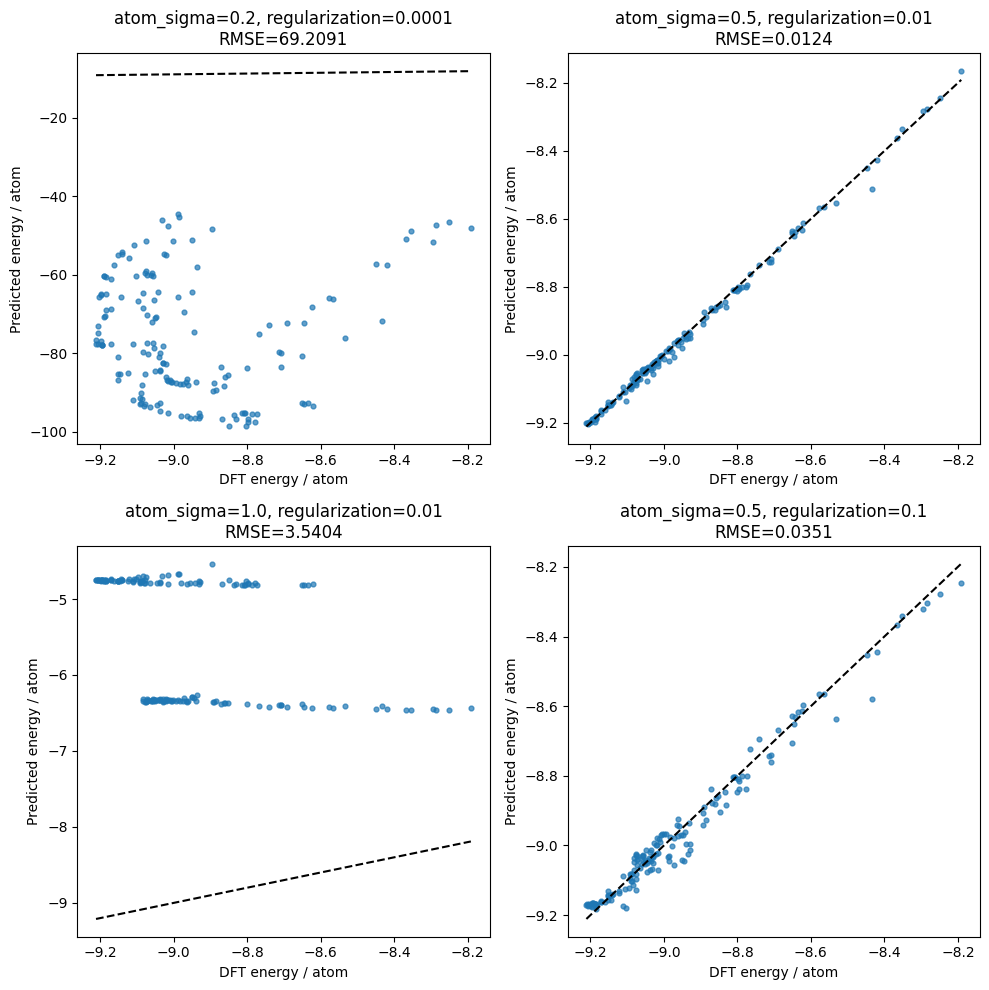

In [72]:
selected_settings = [
    (0.2, 1e-4),   # very sharp + very small regularization
    (0.5, 1e-2),   
    (1.0, 1e-2),   
    (0.5, 1e-1),   # stronger regularization
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, (atom_sigma, sigma_n) in zip(axes.ravel(), selected_settings):
    descriptor = make_soap_descriptor(atom_sigma=atom_sigma)
    #X_train, e_train = build_atomic_dataset(train_structures, descriptor)
    alpha, K, L = train_gap_like_model(X_train, e_train, sigma_n=sigma_n, zeta=4)
    y_true, y_pred = predict_dataset(test_structures, descriptor, X_train, alpha, zeta=4)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    ax.scatter(y_true, y_pred, s=12, alpha=0.7)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], "k--")
    ax.set_title(f"atom_sigma={atom_sigma}, regularization={sigma_n}\nRMSE={rmse:.4f}")
    ax.set_xlabel("DFT energy / atom")
    ax.set_ylabel("Predicted energy / atom")

plt.tight_layout()
plt.show()

In [39]:
# Compute SOAP kernel
K = soap_kernel_matrix(X_train, X_train, zeta=zeta)

# Add regularization
K += sigma_n**2 * np.eye(len(X_train))

In [40]:
L = np.linalg.cholesky(K) 
z = np.linalg.solve(L, e_train) # solve 

alpha = np.linalg.solve(L.T, z)  # we basically got our model!


In [41]:
model1=alpha.copy() #store the model
print("Alpha is a vector of the same length of our energies:", alpha.shape)

Alpha is a vector of the same length of our energies: (1196,)


In [44]:
def predict_structure_energy(atoms, descriptor, X_train_all, alpha, zeta=4):
    """Predict total energy for a new structure using our model."""
    desc = descriptor.calc(atoms,properties=['energy'], descriptor_only=True)
  
    X_test = desc['data']  
    
    # Kernel between test atoms and training atoms
    K_test = soap_kernel_matrix(X_test, X_train_all, zeta=zeta) 
    # Predict local energies and sum
    local_energies = np.dot(K_test, alpha) 
    total_energy = np.sum(local_energies)
    return total_energy

In [46]:
test_structures = read("bulk_cryst_test.xyz", index=":100")
E_preds = [predict_structure_energy(a, soap_descriptor, X_train, alpha) for a in test_structures]
E_pred_atom = [E_preds[i]/len(test_structures[i]) for i in range(0, len(test_structures))]
print(f"We predicted {len(E_preds)} energies of the test set using our GAP model")
E_dft = [a.get_potential_energy()/len(a) for a in test_structures]

We predicted 100 energies of the test set using our GAP model


In [48]:
from sklearn.metrics import r2_score, mean_squared_error
def parity_plot(y_true, y_pred, title="Parity Plot", xlabel="DFT Energy (eV)", ylabel="Predicted Energy (eV)"):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Compute metrics
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # Plot
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, s=10, alpha=0.7, label='Data')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2, label='Ideal')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.axis('equal')
    plt.legend()
    plt.text(0.05, 0.95, f"$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f} eV",
             transform=plt.gca().transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle="round", facecolor='white', alpha=0.8))
    plt.tight_layout()
    plt.show()

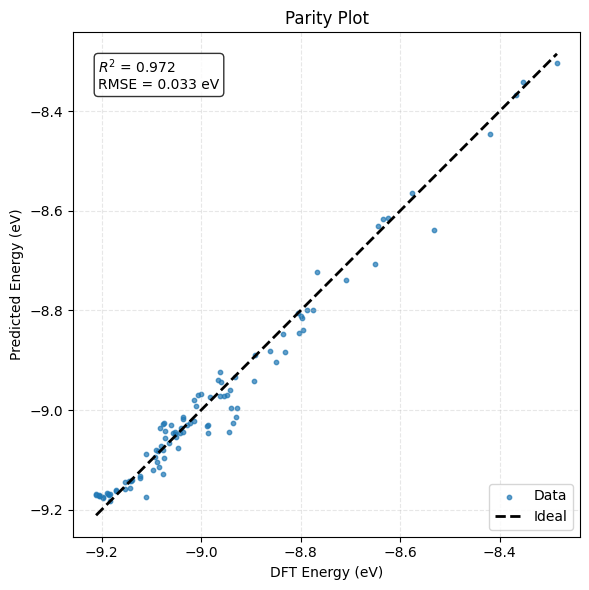

In [49]:
parity_plot(E_dft, E_pred_atom)

In [2]:
! gap_fit \
  energy_parameter_name=free_energy \
  force_parameter_name=forces \
  virial_parameter_name=DUMMY \
  at_file=a_C_db_train.xyz \
  gap="SOAP cutoff=3.0 l_max=4 n_max=4 atom_sigma=0.5 zeta=4 delta=1.0  n_species=1 species_Z=6\
  n_sparse=500 sparse_method=cur_points covariance_type=dot_product" \
  default_sigma={0.001 0.01 0.0 0.0} \
  e0=0.0 \
  do_copy_at_file=F \
  gp_file=C_GAP.xml

libAtoms::Hello World: 2026-03-12 15:40:57
libAtoms::Hello World: git version  https://github.com/libatoms/QUIP.git,v0.10.2-dirty
libAtoms::Hello World: QUIP_ARCH    linux_x86_64_gfortran
libAtoms::Hello World: compiled on  Mar 12 2026 at 15:22:31
libAtoms::Hello World: Random Seed = 56457656
libAtoms::Hello World: global verbosity = 0

Calls to system_timer will do nothing by default


================================ Input parameters ==============================

config_file =
atoms_filename = //MANDATORY//
at_file = a_C_db_train.xyz
gap = "SOAP cutoff=3.0 l_max=4 n_max=4 atom_sigma=0.5 zeta=4 delta=1.0  n_species=1 species_Z=6   n_sparse=500 sparse_method=cur_points covariance_type=dot_product"
e0 = 0.0
local_property0 = 0.0
e0_offset = 0.0
e0_method = isolated
default_kernel_regularisation = //MANDATORY//
default_sigma = "0.001 0.01 0.0 0.0"
default_kernel_regularisation_local_property = 0.001
default_local_property_sigma = 0.001
sparse_jitter = 1.0e-10
hessian_displacement = 1.0